# Laboratorio 2 — Deep Learning (LSTM)

Fabian Prado Dluzniewski — 23427

## Ejercicio 1. Modelos LSTM para las series de País (Top 3)

Se usan las mismas series y los mismos conjuntos de entrenamiento y prueba del
Laboratorio 1: base Turista + Excursionista, agregación mensual, ventana
2009-01 a 2022-12 para País y división temporal 70/30 sin barajar.

### IMPORTS

In [1]:
import os
import random
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")

DISPOSITIVO = torch.device("cpu")
SEMILLAS = [42, 7]
VAL_MESES = 24
PACIENCIA = 30


def fijar_semilla(semilla):
    os.environ["PYTHONHASHSEED"] = str(semilla)
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)


print("PyTorch:", torch.__version__)

PyTorch: 2.13.0


### LECTURA DE DATOS

In [2]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")

df_ts = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()
df_ts["Fecha"] = pd.to_datetime(
    dict(year=df_ts["Año"], month=df_ts["Mes cod"], day=1)
)
calendario = pd.date_range(df_ts["Fecha"].min(), df_ts["Fecha"].max(), freq="MS")


def serie_mensual(datos, filtro_col=None, filtro_val=None):
    subset = datos if filtro_col is None else datos[datos[filtro_col] == filtro_val]
    return (
        subset.groupby("Fecha")["Viajero"].sum()
        .reindex(calendario, fill_value=0)
        .astype(float)
        .asfreq("MS")
    )


def dividir_serie(serie, proporcion=0.70):
    corte = int(np.floor(len(serie) * proporcion))
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()


top3_paises = (
    df_ts[df_ts["Año"] <= 2022]
    .groupby("País")["Viajero"].sum().nlargest(3).index.tolist()
)
series_paises = {
    pais: serie_mensual(df_ts, "País", pais).loc[:"2022-12-01"]
    for pais in top3_paises
}
divisiones = {pais: dividir_serie(s) for pais, s in series_paises.items()}

print("Top 3 países (mismos del Laboratorio 1):", ", ".join(top3_paises))

Top 3 países (mismos del Laboratorio 1): Guatemala, El Salvador, Estados Unidos de América


## 1.1. Conjuntos de entrenamiento y prueba

La división es la misma del Laboratorio 1 (70/30 temporal). El conjunto de
prueba de cada país tiene 51 meses e incluye todo el choque de 2020. Se
mantiene igual para poder comparar las LSTM contra los modelos clásicos del
laboratorio anterior.

In [3]:
resumen_division = pd.DataFrame([
    {
        "Serie": pais,
        "Inicio": s.index.min(),
        "Fin": s.index.max(),
        "Meses": len(s),
        "n_train": len(divisiones[pais][0]),
        "n_test": len(divisiones[pais][1]),
        "Inicio prueba": divisiones[pais][1].index.min(),
        "Promedio prueba": divisiones[pais][1].mean(),
    }
    for pais, s in series_paises.items()
])
display(resumen_division.style.format({"Promedio prueba": "{:,.0f}"}))

,Serie,Inicio,Fin,Meses,n_train,n_test,Inicio prueba,Promedio prueba
0,Guatemala,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"88,013"
1,El Salvador,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"50,298"
2,Estados Unidos de América,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"26,849"


## 1.2. Preprocesamiento y diseño de los modelos

Escala: se aplica `log1p` y luego `MinMaxScaler` a [0,1]. El escalador se
ajusta solo con entrenamiento.

Ventanas: cada observación se convierte en un par (ventana de `lookback`
meses, siguiente valor o siguientes `h` valores). Con `lookback = 12` se cubre
el ciclo anual.

Modelo A (recursiva): salida de 1 paso, realimenta su propia predicción.

Modelo B (directa): salida de `h` pasos en una sola pasada.

Tuneo: los últimos 24 meses del entrenamiento se usan como validación interna
y se selecciona por RMSE. Cada configuración se entrena con 2 semillas y se
promedia. El conjunto de prueba no se usa en el tuneo.

### UTILIDADES: ESCALADO, VENTANAS, PRONÓSTICO Y MÉTRICAS

In [4]:
def preparar_escalador(train):
    escalador = MinMaxScaler(feature_range=(0, 1))
    escalador.fit(np.log1p(train.to_numpy(dtype=float)).reshape(-1, 1))
    return escalador


def escalar(valores, escalador):
    log_vals = np.log1p(np.asarray(valores, dtype=float)).reshape(-1, 1)
    return escalador.transform(log_vals).ravel()


def desescalar(valores_escalados, escalador):
    log_vals = escalador.inverse_transform(
        np.asarray(valores_escalados, dtype=float).reshape(-1, 1)
    ).ravel()
    return np.maximum(0.0, np.expm1(log_vals))


def crear_ventanas(serie_escalada, lookback, horizonte=1):
    X, y = [], []
    for i in range(len(serie_escalada) - lookback - horizonte + 1):
        X.append(serie_escalada[i:i + lookback])
        y.append(serie_escalada[i + lookback:i + lookback + horizonte])
    if not X:
        return np.empty((0, lookback, 1)), np.empty((0, horizonte))
    return (
        np.asarray(X, dtype="float32").reshape(-1, lookback, 1),
        np.asarray(y, dtype="float32").reshape(-1, horizonte),
    )


def pronostico_recursivo(modelo, ventana_inicial, pasos):
    lookback = len(ventana_inicial)
    ventana = list(np.asarray(ventana_inicial, dtype="float32"))
    predicciones = []
    modelo.eval()
    with torch.no_grad():
        for _ in range(pasos):
            entrada = torch.tensor(
                np.asarray(ventana[-lookback:], dtype="float32").reshape(1, lookback, 1)
            )
            siguiente = float(modelo(entrada).numpy().ravel()[0])
            predicciones.append(siguiente)
            ventana.append(siguiente)
    return np.asarray(predicciones)


def metricas(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_real, y_pred))),
    }

### ARQUITECTURA Y ENTRENAMIENTO

In [5]:
class RedLSTM(nn.Module):
    def __init__(self, unidades, capas, dropout, salida):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=unidades, num_layers=capas,
            batch_first=True, dropout=dropout if capas > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(unidades, salida)

    def forward(self, x):
        salidas, _ = self.lstm(x)
        return self.fc(self.dropout(salidas[:, -1, :]))


class Historia:
    def __init__(self, registro):
        self.history = registro


def entrenar_y_pronosticar(train, config, horizonte, semilla, verbose=0):
    fijar_semilla(semilla)
    lookback = config["lookback"]
    escalador = preparar_escalador(train)
    y_esc = escalar(train.to_numpy(), escalador)

    salida = 1 if config["arquitectura"] == "recursiva" else horizonte
    X, y = crear_ventanas(y_esc, lookback, salida)
    if len(X) < 12:
        return None, None, None

    corte = int(len(X) * 0.85)
    X_tr, y_tr = torch.tensor(X[:corte]), torch.tensor(y[:corte])
    X_va, y_va = torch.tensor(X[corte:]), torch.tensor(y[corte:])

    modelo = RedLSTM(config["unidades"], config["capas"], config["dropout"], salida)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["lr"])
    perdida_fn = nn.MSELoss()

    registro = {"loss": [], "val_loss": []}
    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    n, batch = len(X_tr), config["batch"]

    for epoca in range(config["epochs"]):
        modelo.train()
        acumulado = 0.0
        for i in range(0, n, batch):
            xb, yb = X_tr[i:i + batch], y_tr[i:i + batch]
            optimizador.zero_grad()
            perdida = perdida_fn(modelo(xb), yb)
            perdida.backward()
            optimizador.step()
            acumulado += perdida.item() * len(xb)

        modelo.eval()
        with torch.no_grad():
            val = perdida_fn(modelo(X_va), y_va).item()

        registro["loss"].append(acumulado / n)
        registro["val_loss"].append(val)

        if val < mejor_val - 1e-6:
            mejor_val, sin_mejora = val, 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA:
                break
        if verbose and epoca % 50 == 0:
            print(f"  época {epoca}: train={registro['loss'][-1]:.5f} val={val:.5f}")

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    modelo.eval()
    with torch.no_grad():
        if config["arquitectura"] == "recursiva":
            pred_esc = pronostico_recursivo(modelo, y_esc[-lookback:], horizonte)
        else:
            entrada = torch.tensor(
                y_esc[-lookback:].reshape(1, lookback, 1).astype("float32")
            )
            pred_esc = modelo(entrada).numpy().ravel()

    return desescalar(pred_esc, escalador), modelo, Historia(registro)

### REJILLA DE CONFIGURACIONES

In [6]:
def cfg(arquitectura, lookback, unidades, capas, dropout, lr=1e-3, epochs=400, batch=8):
    return {
        "arquitectura": arquitectura, "lookback": lookback, "unidades": unidades,
        "capas": capas, "dropout": dropout, "lr": lr, "epochs": epochs, "batch": batch,
    }


CONFIGS_A = [
    cfg("recursiva", 12, 32, 1, 0.0),
    cfg("recursiva", 12, 64, 1, 0.1),
    cfg("recursiva", 12, 32, 2, 0.2),
    cfg("recursiva", 24, 32, 1, 0.0),
    cfg("recursiva", 24, 64, 2, 0.2),
    cfg("recursiva", 12, 64, 1, 0.1, lr=5e-4),
]

CONFIGS_B = [
    cfg("directa", 12, 32, 1, 0.0),
    cfg("directa", 12, 64, 1, 0.1),
    cfg("directa", 12, 64, 2, 0.2),
    cfg("directa", 24, 32, 1, 0.1),
    cfg("directa", 24, 64, 1, 0.2),
    cfg("directa", 12, 128, 1, 0.2, lr=5e-4),
]


def etiqueta(config):
    return (f"{config['arquitectura']}|lb={config['lookback']}|u={config['unidades']}"
            f"|capas={config['capas']}|drop={config['dropout']}|lr={config['lr']:g}")


print(f"{len(CONFIGS_A)} configuraciones A + {len(CONFIGS_B)} configuraciones B "
      f"× {len(SEMILLAS)} semillas × {len(series_paises)} series = "
      f"{(len(CONFIGS_A)+len(CONFIGS_B))*len(SEMILLAS)*len(series_paises)} ajustes")

6 configuraciones A + 6 configuraciones B × 2 semillas × 3 series = 72 ajustes


### TUNEO DE PARÁMETROS

In [7]:
def tunear(train, configs, horizonte_val=VAL_MESES, semillas=SEMILLAS):
    sub_train = train.iloc[:-horizonte_val]
    sub_val = train.iloc[-horizonte_val:]
    filas = []
    for config in configs:
        rmses, maes = [], []
        for semilla in semillas:
            pred, _, _ = entrenar_y_pronosticar(sub_train, config, horizonte_val, semilla)
            if pred is None:
                break
            m = metricas(sub_val.to_numpy(), pred)
            rmses.append(m["RMSE"]); maes.append(m["MAE"])
        if not rmses:
            continue
        filas.append({
            "Arquitectura": "A. Recursiva" if config["arquitectura"] == "recursiva" else "B. Directa",
            "Configuración": etiqueta(config),
            "MAE_val": float(np.mean(maes)),
            "RMSE_val": float(np.mean(rmses)),
            "RMSE_sd": float(np.std(rmses)),
            "_config": config,
        })
    return pd.DataFrame(filas).sort_values("RMSE_val").reset_index(drop=True)


tuneos = {}
for pais, (train, test) in divisiones.items():
    print(f"\n=== Tuneando {pais} ===")
    tabla = pd.concat(
        [tunear(train, CONFIGS_A), tunear(train, CONFIGS_B)],
        ignore_index=True,
    ).sort_values(["Arquitectura", "RMSE_val"]).reset_index(drop=True)
    tuneos[pais] = tabla
    display(
        tabla.drop(columns="_config").style.format(
            {"MAE_val": "{:,.0f}", "RMSE_val": "{:,.0f}", "RMSE_sd": "{:,.0f}"}
        ).set_caption(f"Tuneo — {pais} (validación: últimos {VAL_MESES} meses de train)")
    )


=== Tuneando Guatemala ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"17,005","23,388",640
1,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"17,140","23,465",406
2,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"18,159","25,331",362
3,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"19,315","25,997","4,363"
4,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"20,271","27,079",618
5,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"20,627","27,238","2,585"
6,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"30,238","35,488","1,381"
7,B. Directa,directa|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"32,332","37,541","5,955"
8,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"31,781","39,372","3,265"
9,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"35,625","42,242","2,720"



=== Tuneando El Salvador ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"18,396","25,804","1,774"
1,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"18,372","25,890",603
2,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"18,931","26,475","1,425"
3,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"21,451","28,548","4,760"
4,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"21,315","28,707",5
5,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"25,393","32,410",63
6,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"25,756","32,791","2,218"
7,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"25,827","33,211","5,814"
8,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"29,793","35,948",795
9,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"30,632","37,060",81



=== Tuneando Estados Unidos de América ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"5,365","7,061","2,402"
1,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"7,186","9,228",81
2,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"6,990","9,784",163
3,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"7,034","9,887",102
4,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"7,373","10,333",117
5,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"7,425","10,395",184
6,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"5,064","6,996","3,060"
7,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"5,568","7,361","3,067"
8,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"5,309","7,496","3,212"
9,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"7,034","9,738","1,059"


### 1.3. MEJOR MODELO DE CADA ARQUITECTURA Y PREDICCIÓN SOBRE PRUEBA

In [8]:
resultados_lstm = {}
filas_prueba = []

for pais, (train, test) in divisiones.items():
    tabla = tuneos[pais]
    resultados_lstm[pais] = {}
    for arq in ["A. Recursiva", "B. Directa"]:
        mejor = tabla[tabla["Arquitectura"] == arq].sort_values("RMSE_val").iloc[0]
        config = mejor["_config"]
        preds_semillas = []
        for semilla in SEMILLAS:
            pred, modelo, historia = entrenar_y_pronosticar(
                train, config, len(test), semilla
            )
            preds_semillas.append(pred)
        pred_media = pd.Series(np.mean(preds_semillas, axis=0), index=test.index)
        m = metricas(test.to_numpy(), pred_media)
        resultados_lstm[pais][arq] = {
            "config": config, "pred": pred_media, "historia": historia, **m
        }
        filas_prueba.append({
            "Serie": pais, "Modelo": arq, "Configuración": etiqueta(config),
            "RMSE_val": mejor["RMSE_val"], "MAE_prueba": m["MAE"], "RMSE_prueba": m["RMSE"],
            "RMSE / promedio prueba (%)": 100 * m["RMSE"] / test.mean(),
        })
        print(f"{pais} — {arq}: RMSE prueba = {m['RMSE']:,.0f}")

comparacion_lstm = pd.DataFrame(filas_prueba)
display(comparacion_lstm.style.format({
    "RMSE_val": "{:,.0f}", "MAE_prueba": "{:,.0f}",
    "RMSE_prueba": "{:,.0f}", "RMSE / promedio prueba (%)": "{:.1f}%",
}))

Guatemala — A. Recursiva: RMSE prueba = 217,450
Guatemala — B. Directa: RMSE prueba = 114,690
El Salvador — A. Recursiva: RMSE prueba = 257,431
El Salvador — B. Directa: RMSE prueba = 47,997
Estados Unidos de América — A. Recursiva: RMSE prueba = 16,903
Estados Unidos de América — B. Directa: RMSE prueba = 16,618


,Serie,Modelo,Configuración,RMSE_val,MAE_prueba,RMSE_prueba,RMSE / promedio prueba (%)
0,Guatemala,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"23,388","183,273","217,450",247.1%
1,Guatemala,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"35,488","100,719","114,690",130.3%
2,El Salvador,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"25,804","212,217","257,431",511.8%
3,El Salvador,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"32,791","43,830","47,997",95.4%
4,Estados Unidos de América,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"7,061","13,553","16,903",63.0%
5,Estados Unidos de América,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"6,996","13,896","16,618",61.9%


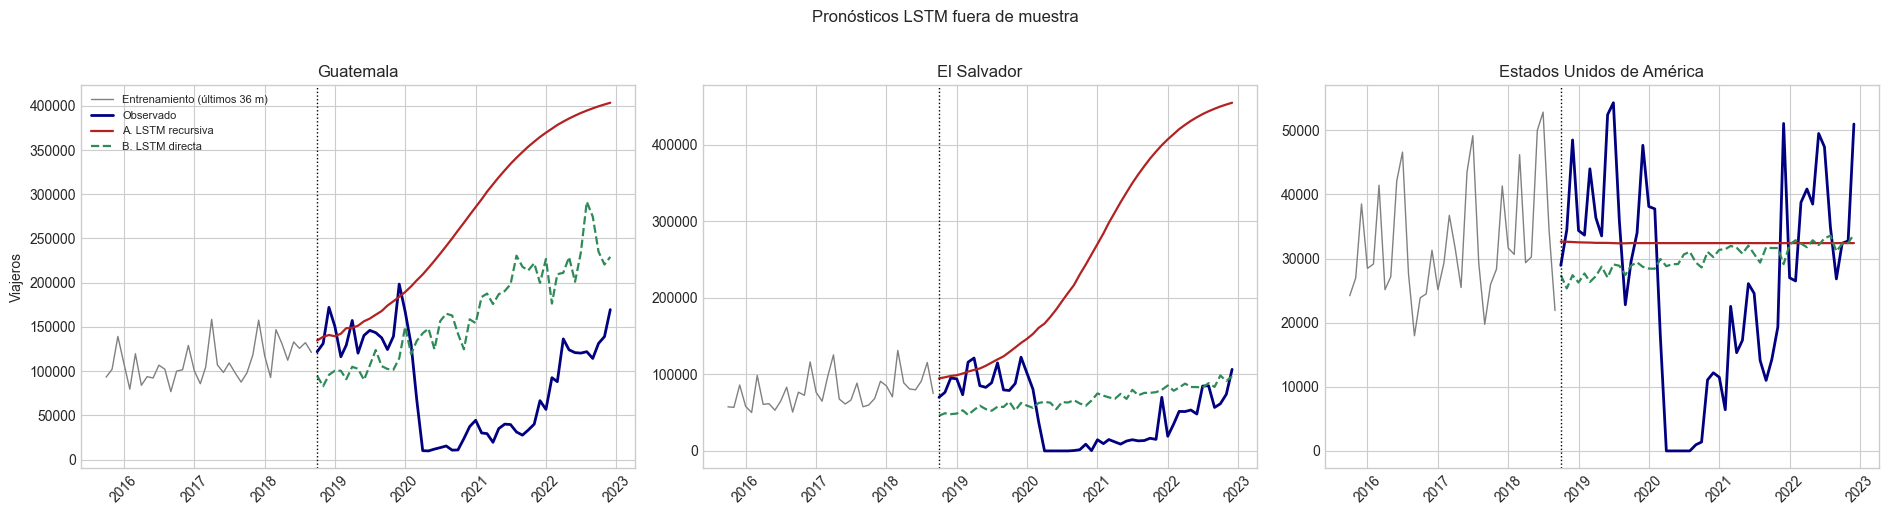

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (pais, (train, test)) in zip(axes, divisiones.items()):
    ax.plot(train.iloc[-36:], color="gray", lw=1, label="Entrenamiento (últimos 36 m)")
    ax.plot(test, color="navy", lw=2, label="Observado")
    ax.plot(resultados_lstm[pais]["A. Recursiva"]["pred"], color="firebrick",
            lw=1.6, label="A. LSTM recursiva")
    ax.plot(resultados_lstm[pais]["B. Directa"]["pred"], color="seagreen",
            lw=1.6, ls="--", label="B. LSTM directa")
    ax.axvline(test.index[0], color="black", ls=":", lw=1)
    ax.set_title(pais)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Viajeros")
axes[0].legend(fontsize=8)
fig.suptitle("Pronósticos LSTM fuera de muestra", y=1.02)
plt.tight_layout()
plt.show()

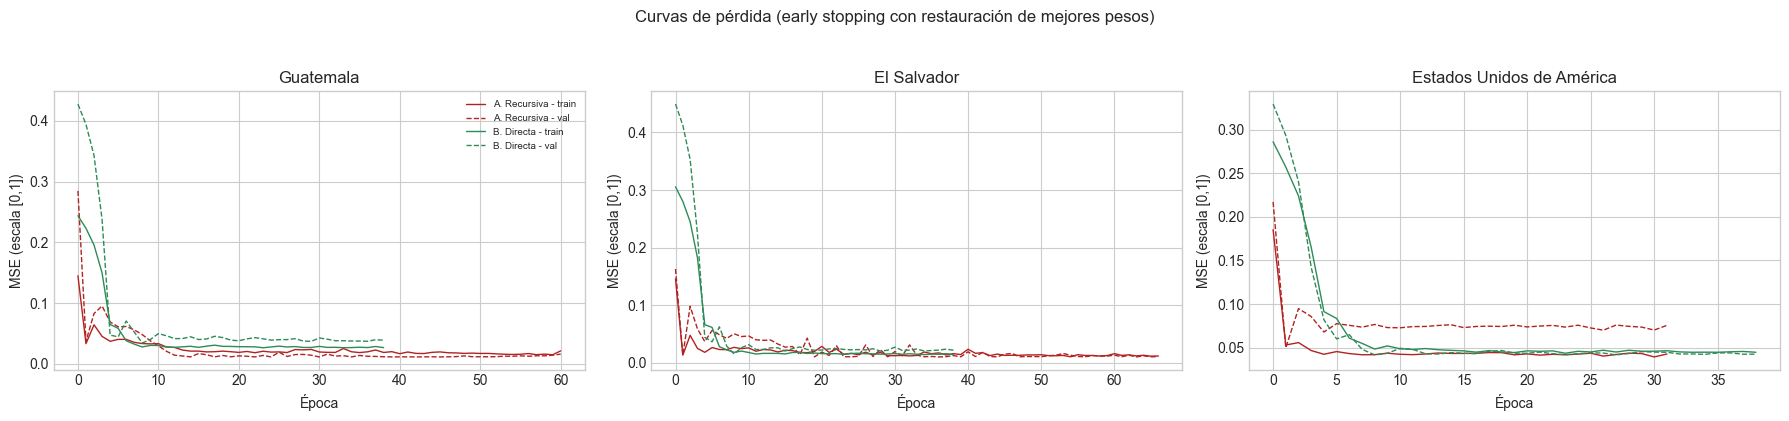

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, pais in zip(axes, divisiones):
    for arq, color in [("A. Recursiva", "firebrick"), ("B. Directa", "seagreen")]:
        h = resultados_lstm[pais][arq]["historia"].history
        ax.plot(h["loss"], color=color, lw=1, label=f"{arq} - train")
        ax.plot(h["val_loss"], color=color, lw=1, ls="--", label=f"{arq} - val")
    ax.set_title(pais); ax.set_xlabel("Época"); ax.set_ylabel("MSE (escala [0,1])")
axes[0].legend(fontsize=7)
fig.suptitle("Curvas de pérdida (early stopping con restauración de mejores pesos)", y=1.04)
plt.tight_layout()
plt.show()

## 1.3-1.4. Comparación contra los modelos del Laboratorio 1

Las referencias son los mejores modelos por RMSE del Laboratorio 1 sobre la
misma partición. Se agrega Seasonal naïve como piso de comparación.

In [11]:
baseline_lab1 = {
    "Guatemala": ("Suavizamiento exponencial", 51_965, 66_129),
    "El Salvador": ("ARIMA(4, 1, 3)", 42_141, 53_001),
    "Estados Unidos de América": ("ARIMA(2, 1, 4)", 13_458, 16_746),
}

filas_final = []
for pais, (train, test) in divisiones.items():
    snaive = pd.Series(np.resize(train.iloc[-12:].to_numpy(), len(test)), index=test.index)
    m_sn = metricas(test.to_numpy(), snaive)
    nombre_l1, mae_l1, rmse_l1 = baseline_lab1[pais]

    filas_final += [
        {"Serie": pais, "Origen": "Lab 1", "Modelo": nombre_l1, "MAE": mae_l1, "RMSE": rmse_l1},
        {"Serie": pais, "Origen": "Referencia", "Modelo": "Seasonal naïve", **m_sn},
    ]
    for arq in ["A. Recursiva", "B. Directa"]:
        r = resultados_lstm[pais][arq]
        filas_final.append({"Serie": pais, "Origen": "Lab 2",
                            "Modelo": f"LSTM {arq}", "MAE": r["MAE"], "RMSE": r["RMSE"]})

tabla_final = pd.DataFrame(filas_final)
tabla_final["Δ RMSE vs Lab 1 (%)"] = tabla_final.apply(
    lambda f: 100 * (f["RMSE"] / baseline_lab1[f["Serie"]][2] - 1), axis=1
)
tabla_final = tabla_final.sort_values(["Serie", "RMSE"]).reset_index(drop=True)
display(tabla_final.style.format({
    "MAE": "{:,.0f}", "RMSE": "{:,.0f}", "Δ RMSE vs Lab 1 (%)": "{:+.1f}%"
}))

,Serie,Origen,Modelo,MAE,RMSE,Δ RMSE vs Lab 1 (%)
0,El Salvador,Lab 2,LSTM B. Directa,"43,830","47,997",-9.4%
1,El Salvador,Lab 1,"ARIMA(4, 1, 3)","42,141","53,001",+0.0%
2,El Salvador,Referencia,Seasonal naïve,"43,234","55,242",+4.2%
3,El Salvador,Lab 2,LSTM A. Recursiva,"212,217","257,431",+385.7%
4,Estados Unidos de América,Lab 2,LSTM B. Directa,"13,896","16,618",-0.8%
5,Estados Unidos de América,Lab 1,"ARIMA(2, 1, 4)","13,458","16,746",+0.0%
6,Estados Unidos de América,Lab 2,LSTM A. Recursiva,"13,553","16,903",+0.9%
7,Estados Unidos de América,Referencia,Seasonal naïve,"13,012","17,847",+6.6%
8,Guatemala,Lab 1,Suavizamiento exponencial,"51,965","66,129",+0.0%
9,Guatemala,Referencia,Seasonal naïve,"53,779","67,335",+1.8%


In [12]:
print("LECTURA DE RESULTADOS — LSTM vs LABORATORIO 1")
for pais, (train, test) in divisiones.items():
    sub = tabla_final[tabla_final["Serie"] == pais]
    ganador = sub.iloc[0]
    a = resultados_lstm[pais]["A. Recursiva"]
    b = resultados_lstm[pais]["B. Directa"]
    mejor_lstm = "A. Recursiva" if a["RMSE"] <= b["RMSE"] else "B. Directa"
    peor_lstm = "B. Directa" if mejor_lstm == "A. Recursiva" else "A. Recursiva"
    nombre_l1, _, rmse_l1 = baseline_lab1[pais]
    delta = 100 * (resultados_lstm[pais][mejor_lstm]["RMSE"] / rmse_l1 - 1)

    print(f"\n{pais}  (n_train={len(train)}, n_test={len(test)}, "
          f"promedio de prueba={test.mean():,.0f})")
    print(f"- Mejor LSTM: {mejor_lstm} — RMSE={resultados_lstm[pais][mejor_lstm]['RMSE']:,.0f}, "
          f"MAE={resultados_lstm[pais][mejor_lstm]['MAE']:,.0f}.")
    print(f"  Configuración: {etiqueta(resultados_lstm[pais][mejor_lstm]['config'])}.")
    print(f"- La otra arquitectura ({peor_lstm}) obtuvo "
          f"RMSE={resultados_lstm[pais][peor_lstm]['RMSE']:,.0f}.")
    print(f"- Referencia Lab 1 ({nombre_l1}): RMSE={rmse_l1:,.0f}. "
          f"La mejor LSTM queda {delta:+.1f}% respecto de ese RMSE "
          f"({'peor' if delta > 0 else 'mejor'}).")
    print(f"- Modelo con menor RMSE global de la serie: {ganador['Modelo']} "
          f"({ganador['Origen']}), RMSE={ganador['RMSE']:,.0f}.")

print("\nCRITERIO DE COMPARACIÓN")
print("- RMSE fuera de muestra como criterio principal.")
print("- MAE como evidencia complementaria del error típico mes a mes.")
print("- No se usan AIC/BIC entre familias: una red neuronal y un ARIMA no "
      "comparten verosimilitud ni definición de parámetros.")
print("- Todos los modelos comparten partición, transformación log1p y escala "
      "de reporte en viajeros.")

LECTURA DE RESULTADOS — LSTM vs LABORATORIO 1

Guatemala  (n_train=117, n_test=51, promedio de prueba=88,013)
- Mejor LSTM: B. Directa — RMSE=114,690, MAE=100,719.
  Configuración: directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005.
- La otra arquitectura (A. Recursiva) obtuvo RMSE=217,450.
- Referencia Lab 1 (Suavizamiento exponencial): RMSE=66,129. La mejor LSTM queda +73.4% respecto de ese RMSE (peor).
- Modelo con menor RMSE global de la serie: Suavizamiento exponencial (Lab 1), RMSE=66,129.

El Salvador  (n_train=117, n_test=51, promedio de prueba=50,298)
- Mejor LSTM: B. Directa — RMSE=47,997, MAE=43,830.
  Configuración: directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005.
- La otra arquitectura (A. Recursiva) obtuvo RMSE=257,431.
- Referencia Lab 1 (ARIMA(4, 1, 3)): RMSE=53,001. La mejor LSTM queda -9.4% respecto de ese RMSE (mejor).
- Modelo con menor RMSE global de la serie: LSTM B. Directa (Lab 2), RMSE=47,997.

Estados Unidos de América  (n_train=117, n_test=51, promedio de prueba=2

## Discusión (1.4)

### Respuestas

**¿Cuál predijo mejor entre las dos LSTM?** El Modelo B en las tres series:
RMSE de 114,690 contra 217,450 en Guatemala, 47,997 contra 257,431 en El
Salvador y 16,618 contra 16,903 en Estados Unidos.

**¿Son mejores que los modelos del Laboratorio 1?** Solo en parte. El
Salvador mejora (47,997 contra 53,001 del ARIMA(4,1,3), −9.4%). Estados
Unidos empata (−0.8%). Guatemala pierde (114,690 contra 66,129 del
suavizamiento exponencial, +73.4%).

**¿Cómo se determinó?** Con RMSE fuera de muestra como criterio principal y
MAE como complemento, sobre la misma partición, la misma transformación
`log1p` y la misma escala de reporte. No se usan AIC/BIC entre familias
porque una red neuronal y un ARIMA no comparten verosimilitud.

### Por qué fallaron

Hay dos causas distintas.

**1. El cambio estructural de 2020.** El entrenamiento termina en septiembre
de 2018 y la prueba va de octubre 2018 a diciembre 2022. En medio está el
cierre de fronteras: Guatemala pasa de un máximo cercano a 190,000 viajeros
mensuales a valores casi nulos en 2020. Los nueve años de entrenamiento no
contienen nada parecido, así que ningún modelo podía anticiparlo. Por eso
todos los RMSE quedan entre 62% y 130% del promedio de prueba.

**2. La realimentación recursiva del Modelo A.** El modelo predice un mes a
la vez y usa su propia salida como entrada del siguiente paso. A partir del
mes 13 ya no ve datos reales. Como aprendió que la serie crece, repite ese
sesgo 51 veces: con un sesgo de 2.2% mensual, 1.022^51 ≈ 3.0, o sea de
130,000 a 400,000. Modelar en escala logarítmica amplifica el efecto al
invertir con `expm1`. El resultado es que la realidad cayó a cero mientras el
pronóstico subía a 400,000 en Guatemala y 460,000 en El Salvador.

El Modelo B no acumula error porque emite los 51 pasos de una sola vez. Su
pronóstico es una trayectoria suave y conservadora: no acierta, pero se
equivoca sin escalar.

El suavizamiento exponencial ganó en Guatemala porque pronostica una línea
plana en el último nivel observado, cerca de 130,000. Contra una realidad que
va de 10,000 a 190,000 esa línea está mal, pero mucho menos que una rampa a
400,000. Cuando el futuro tiene un régimen que no está en el entrenamiento,
no extrapolar tendencia funciona mejor que extrapolarla.

### Hallazgos

1. **El criterio de selección se invirtió entre validación y prueba.** En
   Guatemala y El Salvador la validación prefirió el Modelo A (RMSE_val de
   23,388 y 25,804) sobre el B (35,488 y 32,791), pero en prueba el orden se
   invierte por factores de 2x y 5x. La validación son los últimos 24 meses
   del entrenamiento (2016-10 a 2018-09), un período estable y con la mitad
   del horizonte de prueba, así que no representa lo que el modelo tiene que
   enfrentar. Estados Unidos es la única serie donde validación y prueba
   coinciden, y también la única cuya prueba no está dominada por un colapso
   a cero.

2. **La LSTM mejora el RMSE pero empeora el MAE** respecto del Laboratorio 1
   en las dos series donde compite: El Salvador 47,997 y 43,830 contra 53,001
   y 42,141; Estados Unidos 16,618 y 13,896 contra 16,746 y 13,458. Comete
   menos errores grandes y algo más de error mes a mes.

3. **Ningún modelo supera con claridad al seasonal naïve** (67,335, 55,242 y
   17,847). Guatemala lo supera por 1.8% y Estados Unidos por 6.6%. Solo el
   Modelo B en El Salvador lo supera por 13%, y con dos semillas y una
   desviación de aproximadamente 1,400 esa ventaja no está claramente fuera
   del ruido.

4. **La complejidad no compensa el tamaño de muestra.** Con 117 meses de
   entrenamiento y `lookback = 12` quedan alrededor de 105 ventanas. La red
   ajusta miles de parámetros contra 2 a 7 de un ARIMA, lo que se refleja en
   la columna `RMSE_sd` del tuneo.

### Limitaciones

1. El Modelo B usa `Dense(51)`, o sea que el horizonte de prueba está
   incorporado en la arquitectura. Es válido porque el horizonte se conoce de
   antemano, pero el modelo queda optimizado para esa longitud.
2. El tuneo se hizo con horizonte de validación de 24 meses y el despliegue
   con 51. Eso perjudicó al Modelo A y favoreció al B.
3. Dos semillas por configuración no eliminan el efecto de la inicialización.
4. El pronóstico recursivo no se acotó al rango histórico. Se dejó así para
   documentar la deriva; acotarlo en [0, 1] en escala MinMax lo habría
   limitado al máximo de entrenamiento.

# Ejercicio 2. Similitud de las series mediante catch22

## 2.1. Idea detrás de catch22

La librería *hctsa* juntó alrededor de 7,700 características propuestas en la
literatura para describir series de tiempo. Ese conjunto es redundante y caro
de calcular. Lubba et al. (2019) lo redujeron en tres pasos: descartaron las
características inestables o dependientes de la escala, evaluaron cuáles
clasificaban bien sobre 93 conjuntos de datos del repositorio UEA/UCR, y
agruparon las restantes por correlación para dejar una representante por
grupo. Quedaron 22 (*CAnonical Time-series CHaracteristics*).

Lo importante es el cambio de representación: cada serie deja de ser una
secuencia de longitud arbitraria y pasa a ser un vector de 22 números. Con eso,
comparar series se convierte en un problema geométrico y se puede aplicar PCA,
clustering y matrices de distancia. También permite comparar series de
longitudes distintas y no requiere conocimiento del dominio.

Las 22 características cubren forma de la distribución, autocorrelación,
predictibilidad y entropía, escalamiento de fluctuaciones (DFA), rachas y
valores extremos, y no linealidad.

La mayoría de las características normaliza internamente la serie, así que son
aproximadamente invariantes al nivel y a la escala. Dos series con volúmenes
muy distintos pueden quedar cerca si su forma es parecida.

### 2.2-2.3. EXTRACCIÓN DE CARACTERÍSTICAS Y MATRIZ SERIES × CARACTERÍSTICAS

In [13]:
import pycatch22

top3_regiones = (
    df_ts.groupby("Región dos")["Viajero"].sum().nlargest(3).index.tolist()
)

VENTANA_COMUN = "2022-12-01"

series_catch22 = {"TOTAL (Turista+Excursionista)": serie_mensual(df_ts).loc[:VENTANA_COMUN]}
for pais in top3_paises:
    series_catch22[f"País — {pais}"] = series_paises[pais].loc[:VENTANA_COMUN]
for region in top3_regiones:
    series_catch22[f"Región — {region}"] = (
        serie_mensual(df_ts, "Región dos", region).loc[:VENTANA_COMUN]
    )

print(f"Series a caracterizar: {len(series_catch22)}")
for nombre, s in series_catch22.items():
    print(f"  {nombre:45s} n={len(s):3d}  "
          f"{s.index.min():%Y-%m} a {s.index.max():%Y-%m}  media={s.mean():>10,.0f}")

Series a caracterizar: 7
  TOTAL (Turista+Excursionista)                 n=168  2009-01 a 2022-12  media=   211,850
  País — Guatemala                              n=168  2009-01 a 2022-12  media=    82,562
  País — El Salvador                            n=168  2009-01 a 2022-12  media=    53,325
  País — Estados Unidos de América              n=168  2009-01 a 2022-12  media=    28,027
  Región — América Del Centro                   n=168  2009-01 a 2022-12  media=   155,787
  Región — América Del Norte                    n=168  2009-01 a 2022-12  media=    38,010
  Región — Europa                               n=168  2009-01 a 2022-12  media=     9,319


In [14]:
filas, nombres_features = [], None
for nombre, serie in series_catch22.items():
    resultado = pycatch22.catch22_all(serie.to_numpy(dtype=float).tolist(), catch24=False)
    nombres_features = resultado["names"]
    filas.append(pd.Series(resultado["values"], index=resultado["names"], name=nombre))

matriz_catch22 = pd.DataFrame(filas)
print("Matriz de características:", matriz_catch22.shape, "(series × características)")
display(matriz_catch22.style.format("{:.4f}"))

constantes = matriz_catch22.columns[matriz_catch22.std() == 0].tolist()
print("Características sin variación entre series:", constantes or "ninguna")
print("Valores no finitos:", int((~np.isfinite(matriz_catch22.to_numpy())).sum()))

Matriz de características: (7, 22) (series × características)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
TOTAL (Turista+Excursionista),0.1965,-0.2942,8.6906,10.0000,0.4206,-0.0357,0.9222,42.0000,0.0453,11.0000,0.3550,9.0000,0.0588,0.4524,0.6548,0.8324,6.0000,1.8147,0.8537,0.8537,0.1227,0.5957
País — Guatemala,-0.4196,-0.6642,8.5927,10.0000,0.4755,0.0031,0.9401,42.0000,0.0329,11.0000,0.3716,9.0000,0.0556,0.4702,0.6548,0.8356,6.0000,1.7449,0.8537,0.8537,0.1227,0.5884
País — El Salvador,-0.4863,-0.2569,9.3227,2.0000,0.4233,-0.0100,0.8802,42.0000,0.0206,3.0000,0.2393,1.0000,0.0556,0.4048,0.6607,0.7878,5.0000,1.8657,0.8537,0.8537,0.1227,0.6425
País — Estados Unidos de América,-0.0789,-0.3216,1.7816,2.0000,0.1560,0.0351,0.9281,12.0000,0.0104,3.0000,0.1744,1.0000,0.1000,0.3571,0.6548,0.5786,5.0000,2.1049,0.8537,0.8537,0.3927,0.9233
Región — América Del Centro,-0.5666,-0.3263,8.9074,10.0000,0.4902,-0.0176,0.9102,42.0000,0.0206,11.0000,0.3456,9.0000,0.0556,0.4524,0.6548,0.8366,6.0000,1.8125,0.8537,0.8537,0.1227,0.5838
Región — América Del Norte,0.1259,-0.1121,5.7156,2.0000,0.2381,-0.0368,0.9461,12.0000,0.0052,3.0000,0.2283,1.0000,0.1000,0.2560,0.6607,0.6329,5.0000,2.0967,0.8537,0.8293,0.2209,0.8648
Región — Europa,0.2285,0.4905,4.5715,2.0000,0.3480,0.0294,0.9281,8.0000,0.0133,2.0000,0.2139,1.0000,0.0625,0.2500,0.6786,0.7287,6.0000,2.1005,0.8537,0.7317,0.1718,0.7846


Características sin variación entre series: ['SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1']
Valores no finitos: 0


## 2.4. Estandarización

Se descartan las características con varianza cero entre series, porque no
discriminan y distorsionan las cargas del PCA, y se estandariza el resto con
`StandardScaler`.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score

constantes = matriz_catch22.columns[matriz_catch22.std() == 0].tolist()
matriz_util = matriz_catch22.drop(columns=constantes)
print(f"Se descartan {len(constantes)} características constantes: {constantes}")
print(f"Matriz de trabajo: {matriz_util.shape}")

escalador_c22 = StandardScaler()
Z = pd.DataFrame(
    escalador_c22.fit_transform(matriz_util),
    index=matriz_util.index, columns=matriz_util.columns,
)
print("Verificación — media:", np.round(Z.mean().mean(), 10),
      "| desviación:", np.round(Z.std(ddof=0).mean(), 10))
display(Z.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=-2, vmax=2))

Se descartan 1 características constantes: ['SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1']
Matriz de trabajo: (7, 21)
Verificación — media: -0.0 | desviación: 1.0


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
TOTAL (Turista+Excursionista),1.07,-0.25,0.72,1.15,0.48,-1.16,0.00,0.86,1.88,1.15,1.08,1.15,-0.56,0.87,-0.63,0.87,0.87,-0.81,0.50,-0.64,-0.87
País — Guatemala,-0.87,-1.39,0.68,1.15,0.96,0.29,0.89,0.86,0.92,1.15,1.30,1.15,-0.73,1.08,-0.63,0.90,0.87,-1.28,0.50,-0.64,-0.93
País — El Salvador,-1.08,-0.14,0.96,-0.87,0.51,-0.20,-2.07,0.86,-0.05,-0.80,-0.49,-0.87,-0.73,0.32,0.11,0.41,-1.15,-0.46,0.50,-0.64,-0.52
País — Estados Unidos de América,0.20,-0.34,-1.90,-0.87,-1.80,1.49,0.30,-1.07,-0.84,-0.80,-1.37,-0.87,1.57,-0.24,-0.63,-1.73,-1.15,1.15,0.50,2.27,1.59
Región — América Del Centro,-1.34,-0.35,0.80,1.15,1.08,-0.48,-0.59,0.86,-0.05,1.15,0.95,1.15,-0.73,0.87,-0.63,0.91,0.87,-0.82,0.50,-0.64,-0.97
Región — América Del Norte,0.85,0.31,-0.41,-0.87,-1.09,-1.20,1.18,-1.07,-1.25,-0.80,-0.64,-0.87,1.57,-1.41,0.11,-1.18,-1.15,1.10,-0.08,0.42,1.15
Región — Europa,1.17,2.16,-0.84,-0.87,-0.14,1.27,0.30,-1.32,-0.61,-1.05,-0.83,-0.87,-0.37,-1.48,2.32,-0.19,0.87,1.13,-2.40,-0.11,0.55


## 2.5. PCA, clustering, mapa de calor, correlaciones y distancias

Con 7 series el PCA admite como máximo 6 componentes y el clustering es
descriptivo. Se usa clustering jerárquico en vez de k-means porque el
dendrograma muestra la estructura completa sin fijar k de antemano.

,Componente,Varianza explicada,Acumulada
0,PC1,62.5%,62.5%
1,PC2,16.6%,79.1%
2,PC3,10.8%,89.9%
3,PC4,6.0%,95.9%
4,PC5,2.9%,98.8%
5,PC6,1.2%,100.0%


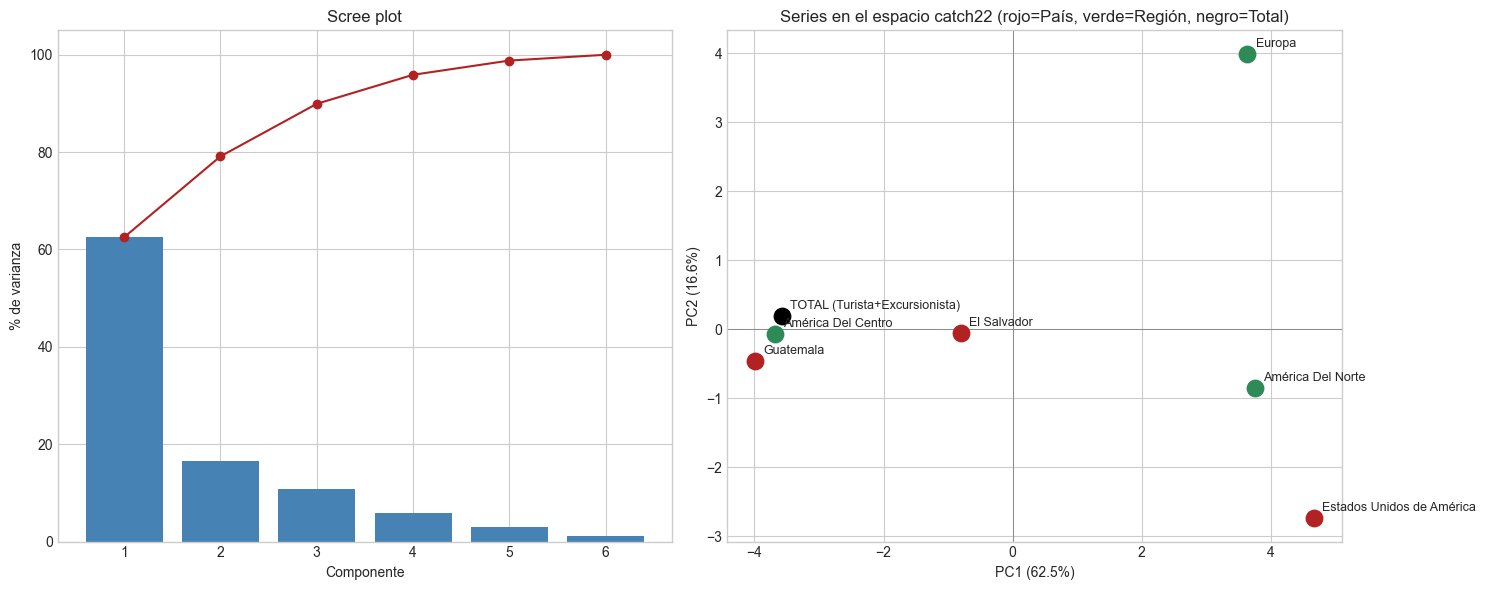


Top 8 características por carga absoluta en PC1:


,PC1,PC2,PC3
SB_MotifThree_quantile_hh,+0.272,+0.038,+0.057
FC_LocalSimple_mean3_stderr,+0.267,-0.114,+0.087
SB_BinaryStats_mean_longstretch1,-0.263,-0.074,-0.168
CO_Embed2_Dist_tau_d_expfit_meandiff,-0.261,+0.022,+0.195
SP_Summaries_welch_rect_area_5_1,-0.257,+0.190,-0.060
CO_HistogramAMI_even_2_5,-0.249,+0.197,-0.111
PD_PeriodicityWang_th0_01,-0.249,-0.067,+0.260
CO_FirstMin_ac,-0.247,-0.028,+0.274


Top 8 características por carga absoluta en PC2:


,PC1,PC2,PC3
DN_OutlierInclude_n_001_mdrmd,+0.140,+0.455,-0.065
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,-0.138,-0.453,-0.090
DN_HistogramMode_10,+0.166,+0.406,-0.020
SB_BinaryStats_diff_longstretch0,-0.167,+0.302,+0.322
FC_LocalSimple_mean1_tauresrat,+0.219,-0.278,+0.163
SP_Summaries_welch_rect_centroid,+0.212,-0.277,+0.120
CO_HistogramAMI_even_2_5,-0.249,+0.197,-0.111
SP_Summaries_welch_rect_area_5_1,-0.257,+0.190,-0.060


In [16]:
pca = PCA(n_components=min(len(Z) - 1, Z.shape[1]))
componentes = pca.fit_transform(Z)
var_exp = pca.explained_variance_ratio_

tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(var_exp))],
    "Varianza explicada": var_exp,
    "Acumulada": np.cumsum(var_exp),
})
display(tabla_pca.style.format({"Varianza explicada": "{:.1%}", "Acumulada": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].bar(range(1, len(var_exp) + 1), 100 * var_exp, color="steelblue")
axes[0].plot(range(1, len(var_exp) + 1), 100 * np.cumsum(var_exp), "o-", color="firebrick")
axes[0].set(xlabel="Componente", ylabel="% de varianza", title="Scree plot")

colores = {"TOTAL": "black", "País": "firebrick", "Región": "seagreen"}
for i, nombre in enumerate(Z.index):
    grupo = "TOTAL" if nombre.startswith("TOTAL") else nombre.split(" —")[0]
    axes[1].scatter(componentes[i, 0], componentes[i, 1], s=140,
                    color=colores.get(grupo, "gray"), zorder=3)
    axes[1].annotate(nombre.replace("País — ", "").replace("Región — ", ""),
                     (componentes[i, 0], componentes[i, 1]),
                     fontsize=9, xytext=(6, 5), textcoords="offset points")
axes[1].axhline(0, color="gray", lw=.6); axes[1].axvline(0, color="gray", lw=.6)
axes[1].set(xlabel=f"PC1 ({var_exp[0]:.1%})", ylabel=f"PC2 ({var_exp[1]:.1%})",
            title="Series en el espacio catch22 (rojo=País, verde=Región, negro=Total)")
plt.tight_layout(); plt.show()

cargas = pd.DataFrame(pca.components_[:3].T, index=Z.columns,
                      columns=["PC1", "PC2", "PC3"])
print("\nTop 8 características por carga absoluta en PC1:")
display(cargas.reindex(cargas["PC1"].abs().sort_values(ascending=False).index)
        .head(8).style.format("{:+.3f}"))
print("Top 8 características por carga absoluta en PC2:")
display(cargas.reindex(cargas["PC2"].abs().sort_values(ascending=False).index)
        .head(8).style.format("{:+.3f}"))

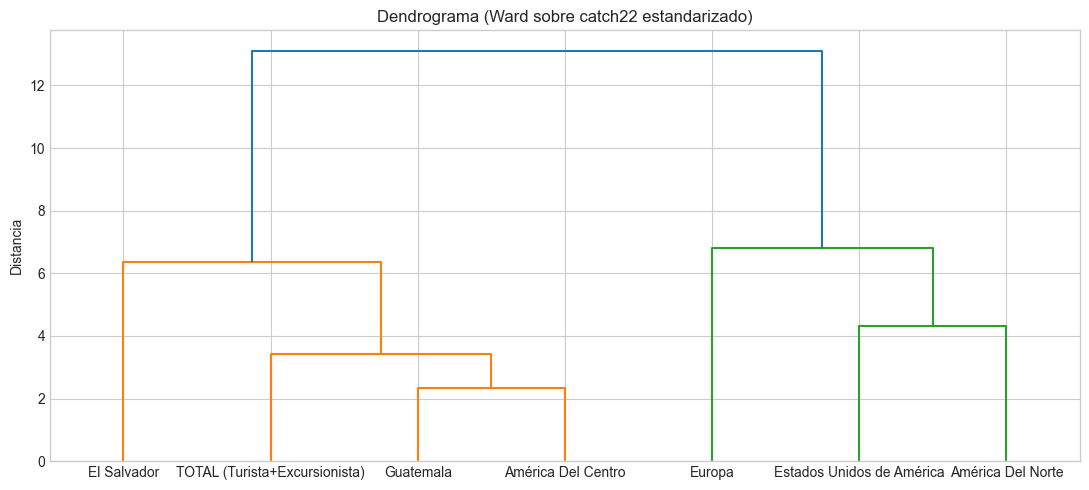

,k,Silhouette,Tamaños
0,2,0.411,"[4, 3]"
1,3,0.361,"[4, 2, 1]"
2,4,0.286,"[3, 1, 2, 1]"



Partición con k=2:
  Grupo 1: TOTAL (Turista+Excursionista), País — Guatemala, País — El Salvador, Región — América Del Centro
  Grupo 2: País — Estados Unidos de América, Región — América Del Norte, Región — Europa


In [17]:
enlaces = linkage(Z.to_numpy(), method="ward")

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(enlaces, labels=[n.replace("País — ", "").replace("Región — ", "")
                            for n in Z.index], ax=ax, leaf_font_size=10)
ax.set(title="Dendrograma (Ward sobre catch22 estandarizado)", ylabel="Distancia")
plt.tight_layout(); plt.show()

filas_sil = []
for k in range(2, 5):
    etiquetas = fcluster(enlaces, k, criterion="maxclust")
    filas_sil.append({"k": k, "Silhouette": silhouette_score(Z, etiquetas),
                      "Tamaños": np.bincount(etiquetas)[1:].tolist()})
display(pd.DataFrame(filas_sil).style.format({"Silhouette": "{:.3f}"}))

k_mejor = int(pd.DataFrame(filas_sil).sort_values("Silhouette", ascending=False).iloc[0]["k"])
grupos = pd.Series(fcluster(enlaces, k_mejor, criterion="maxclust"),
                   index=Z.index, name="Grupo")
print(f"\nPartición con k={k_mejor}:")
for g in sorted(grupos.unique()):
    print(f"  Grupo {g}: {', '.join(grupos[grupos == g].index)}")

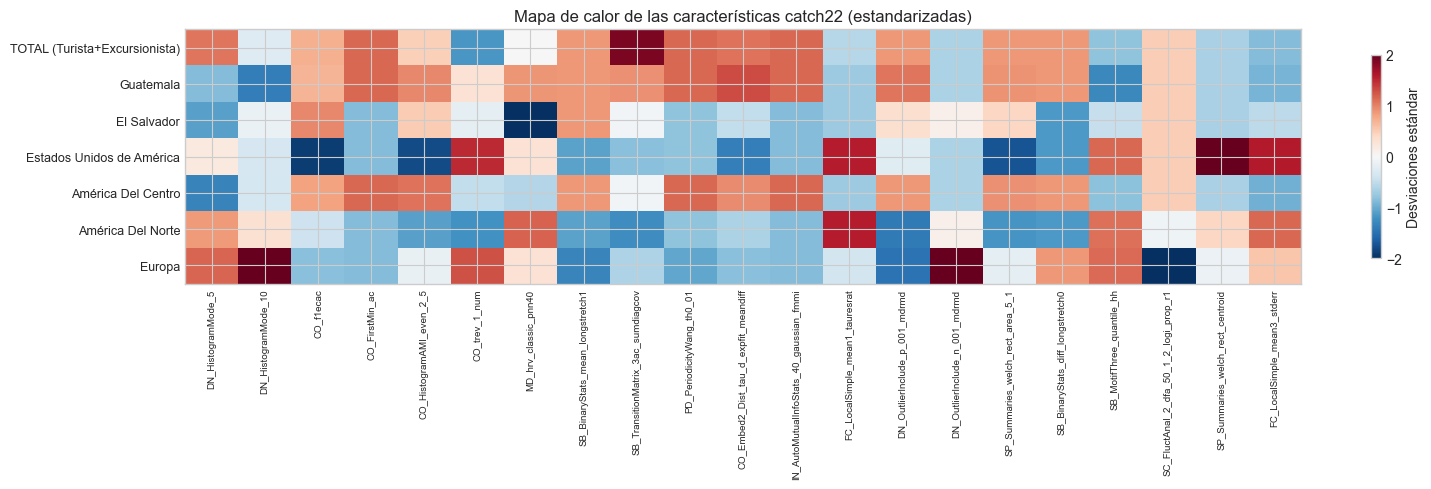

In [18]:
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(Z.to_numpy(), cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(Z.columns)))
ax.set_xticklabels(Z.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(Z.index)))
ax.set_yticklabels([n.replace("País — ", "").replace("Región — ", "") for n in Z.index],
                   fontsize=9)
ax.set_title("Mapa de calor de las características catch22 (estandarizadas)")
fig.colorbar(im, ax=ax, shrink=.8, label="Desviaciones estándar")
plt.tight_layout(); plt.show()

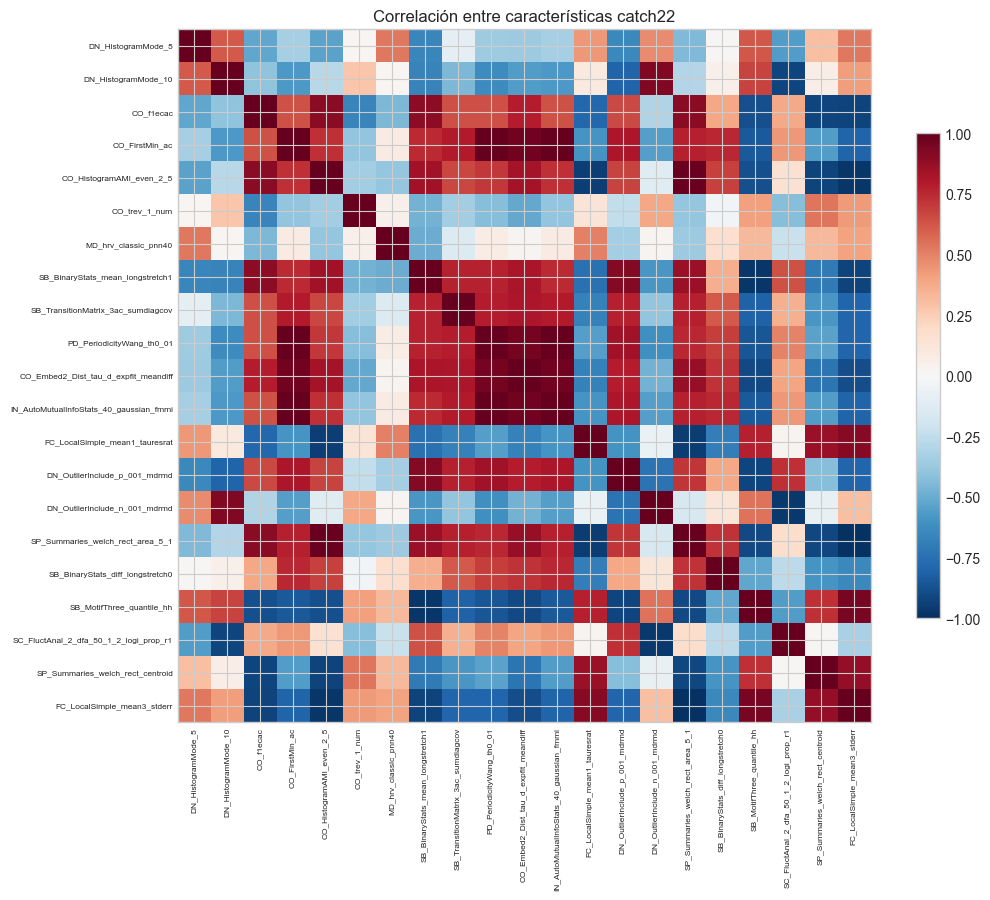

Pares de características más redundantes (|r| > 0.95):


In [19]:
corr_feat = matriz_util.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_feat, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_feat))); ax.set_xticklabels(corr_feat.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr_feat))); ax.set_yticklabels(corr_feat.index, fontsize=6)
ax.set_title("Correlación entre características catch22")
fig.colorbar(im, ax=ax, shrink=.7)
plt.tight_layout(); plt.show()

pares = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool)).stack()
print("Pares de características más redundantes (|r| > 0.95):")
display(pares[pares.abs() > 0.95].sort_values(key=abs, ascending=False)
        .head(12).to_frame("r").style.format("{:+.3f}"))

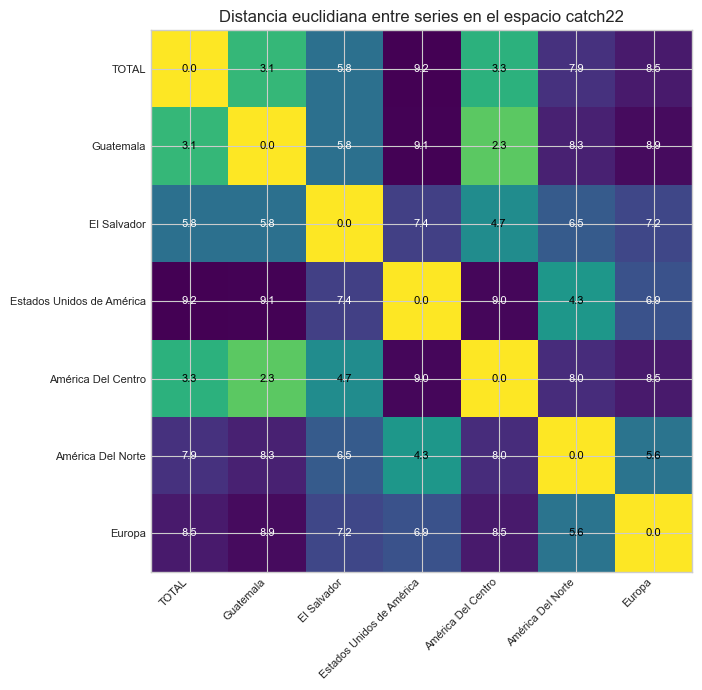

Par más similar:  ('País — Guatemala', 'Región — América Del Centro') → 2.33
Par más distinto: ('TOTAL (Turista+Excursionista)', 'País — Estados Unidos de América') → 9.17

Serie más atípica (mayor distancia promedio al resto):


,Distancia media
País — Estados Unidos de América,7.64
Región — Europa,7.61
Región — América Del Norte,6.78
TOTAL (Turista+Excursionista),6.28
País — Guatemala,6.26
País — El Salvador,6.24
Región — América Del Centro,5.97


In [20]:
distancias = pd.DataFrame(squareform(pdist(Z, metric="euclidean")),
                          index=Z.index, columns=Z.index)
etiquetas_cortas = [n.replace("País — ", "").replace("Región — ", "")
                    .replace(" (Turista+Excursionista)", "") for n in Z.index]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(distancias, cmap="viridis_r")
ax.set_xticks(range(len(Z))); ax.set_xticklabels(etiquetas_cortas, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(Z))); ax.set_yticklabels(etiquetas_cortas, fontsize=8)
for i in range(len(Z)):
    for j in range(len(Z)):
        ax.text(j, i, f"{distancias.iloc[i, j]:.1f}", ha="center", va="center",
                color="white" if distancias.iloc[i, j] > distancias.to_numpy().mean() else "black",
                fontsize=8)
ax.set_title("Distancia euclidiana entre series en el espacio catch22")
plt.tight_layout(); plt.show()

pares_d = distancias.where(np.triu(np.ones(distancias.shape), k=1).astype(bool)).stack()
print(f"Par más similar:  {pares_d.idxmin()} → {pares_d.min():.2f}")
print(f"Par más distinto: {pares_d.idxmax()} → {pares_d.max():.2f}")
print("\nSerie más atípica (mayor distancia promedio al resto):")
display((distancias.sum(axis=1) / (len(Z) - 1)).sort_values(ascending=False)
        .to_frame("Distancia media").style.format("{:.2f}"))

In [21]:
composicion = pd.DataFrame([
    {"Serie": n, "Media mensual": s.mean(),
     "% del TOTAL": 100 * s.mean() / series_catch22["TOTAL (Turista+Excursionista)"].mean()}
    for n, s in series_catch22.items()
])
display(composicion.style.format({"Media mensual": "{:,.0f}", "% del TOTAL": "{:.1f}%"}))

print(f"Guatemala como % de América del Centro: "
      f"{100 * series_catch22['País — Guatemala'].mean() / series_catch22['Región — América Del Centro'].mean():.1f}%")
print(f"Estados Unidos como % de América del Norte: "
      f"{100 * series_catch22['País — Estados Unidos de América'].mean() / series_catch22['Región — América Del Norte'].mean():.1f}%")

corr_series = pd.DataFrame({n: s.to_numpy() for n, s in series_catch22.items()}).corr()
display(corr_series.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

,Serie,Media mensual,% del TOTAL
0,TOTAL (Turista+Excursionista),"211,850",100.0%
1,País — Guatemala,"82,562",39.0%
2,País — El Salvador,"53,325",25.2%
3,País — Estados Unidos de América,"28,027",13.2%
4,Región — América Del Centro,"155,787",73.5%
5,Región — América Del Norte,"38,010",17.9%
6,Región — Europa,"9,319",4.4%


Guatemala como % de América del Centro: 53.0%
Estados Unidos como % de América del Norte: 73.7%


,TOTAL (Turista+Excursionista),País — Guatemala,País — El Salvador,País — Estados Unidos de América,Región — América Del Centro,Región — América Del Norte,Región — Europa
TOTAL (Turista+Excursionista),1.000,0.972,0.956,0.793,0.992,0.834,0.755
País — Guatemala,0.972,1.000,0.913,0.716,0.984,0.738,0.652
País — El Salvador,0.956,0.913,1.000,0.673,0.967,0.715,0.685
País — Estados Unidos de América,0.793,0.716,0.673,1.000,0.727,0.973,0.621
Región — América Del Centro,0.992,0.984,0.967,0.727,1.000,0.763,0.700
Región — América Del Norte,0.834,0.738,0.715,0.973,0.763,1.000,0.731
Región — Europa,0.755,0.652,0.685,0.621,0.700,0.731,1.000


## 2.6-2.13. Análisis e interpretación

### 2.7. ¿Cuáles series presentan comportamientos más similares?

El PCA y el clustering jerárquico dan la misma partición. PC1 concentra 62.5%
de la varianza y PC2 un 16.6% adicional (79.1% acumulado en dos dimensiones),
y el dendrograma de Ward reproduce esa separación:

- Bloque de memoria larga: TOTAL, Guatemala, América del Centro y, de forma
  marginal, El Salvador. Ocupan la mitad negativa de PC1.
- Bloque de memoria corta: Estados Unidos, América del Norte y Europa. Ocupan
  la mitad positiva de PC1.

Las series más similares son Guatemala y América del Centro, que fusionan a
una distancia de Ward cercana a 2.35, seguidas de TOTAL, que se incorpora a
ese par alrededor de 3.45. En el segundo bloque, Estados Unidos y América del
Norte fusionan cerca de 4.3.

Estas tres series del primer grupo no son observaciones independientes:
Guatemala representa cerca del 53% del volumen de América del Centro, y
América del Centro alrededor del 74% del total. Lo mismo ocurre con Estados
Unidos, que es cerca del 74% de América del Norte. La proximidad detectada por
catch22 es en buena parte redundancia composicional por la forma en que se
construyeron las series, no una coincidencia dinámica entre mercados
distintos.

### 2.8. ¿Qué características fueron las más importantes para diferenciar?

Tres características parten la muestra de la misma manera y toman solo dos
valores distintos:

| Característica | Bloque memoria larga | Bloque memoria corta |
|---|---|---|
| `CO_FirstMin_ac` | 10 | 2 |
| `PD_PeriodicityWang_th0_01` | 11 | 3 (Europa: 2) |
| `IN_AutoMutualInfoStats_40_gaussian_fmmi` | 9 | 1 |

Con el mismo patrón de signo en la matriz estandarizada se suman `CO_f1ecac`
(decaimiento de la autocorrelación), `SB_BinaryStats_mean_longstretch1`
(rachas por encima de la media), `SP_Summaries_welch_rect_area_5_1` (potencia
en bajas frecuencias), `CO_Embed2_Dist_tau_d_expfit_meandiff` y, en sentido
inverso, `FC_LocalSimple_mean3_stderr` y `SB_MotifThree_quantile_hh`.

PC1 es entonces un eje de persistencia y predictibilidad. Las series del
primer bloque conservan autocorrelación cerca de un año, tienen su primer
mínimo de autocorrelación en el rezago 10 y concentran potencia en bajas
frecuencias. Las del segundo pierden memoria en dos o tres meses y tienen
mayor entropía de motivos y mayor error de predicción local.

PC2 (16.6%) no separa bloques sino que aísla casos individuales, sobre todo
Europa, mediante características de forma distribucional
(`DN_HistogramMode_10`, `DN_OutlierInclude_n_001_mdrmd`) y de escalamiento de
fluctuaciones (`SC_FluctAnal_2_dfa...`).

### 2.9. ¿Existen grupos naturales?

Sí, dos, y con separación amplia: los dos conglomerados se unen recién a una
distancia cercana a 13.1, contra fusiones internas de 2.4 a 6.8. Lo que
comparten sus miembros es el horizonte de memoria de la serie, no el volumen
ni la geografía. El primer grupo son series de alto volumen, flujo terrestre y
comportamiento persistente; el segundo, series de menor volumen,
principalmente aéreas y con estructura temporal de corto alcance.

Con siete observaciones la partición es descriptiva. No se afirma
significancia estadística.

### 2.10. ¿Las series de una misma categoría se agrupan?

Se agrupan, pero por composición y no por categoría. Guatemala (País) queda
junto a América del Centro (Región) y Estados Unidos (País) junto a América
del Norte (Región). Cada país domina el volumen de su región, así que región y
país describen casi la misma dinámica.

El caso distinto es El Salvador. Pertenece geográficamente al bloque
centroamericano y se incorpora a ese conglomerado, pero lo hace al final, a
una distancia de 6.4, comparable a la fusión interna del bloque opuesto. En la
matriz estandarizada es un híbrido: comparte con el primer bloque las rachas
largas (`SB_BinaryStats_mean_longstretch1` = +0.86) y con el segundo la
memoria corta (`CO_FirstMin_ac` = −0.87, `PD_PeriodicityWang` = −0.80, `fmmi`
= −0.87). Pertenecer a una misma región no implica una misma dinámica
temporal.

### 2.11. Series con el comportamiento más atípico

Hay dos casos atípicos, por motivos distintos.

Estados Unidos es el extremo de PC1. Tiene el decaimiento de autocorrelación
más rápido (`CO_f1ecac` = −1.90 en unidades estandarizadas), la menor potencia
en bajas frecuencias (`SP_Summaries_welch_rect_area_5_1` = −1.73), el
centroide espectral más alto (`SP_Summaries_welch_rect_centroid` = +2.27) y el
mayor error de predicción local (`FC_LocalSimple_mean3_stderr` = +1.59). Es un
flujo aéreo de larga distancia, con decisiones de viaje discrecionales, más
volátil y menos inercial que el tránsito fronterizo terrestre.

Europa es el extremo de PC2 y se separa por la forma de su distribución: es la
única serie con `DN_HistogramMode_10` positivo (+2.16), tiene el valor más
alto en inclusión de valores extremos negativos
(`DN_OutlierInclude_n_001_mdrmd` = +2.32) y el más bajo en escalamiento DFA
(−2.40). Es además la serie de menor volumen (9,319 viajeros mensuales en
promedio), lo que la hace más sensible a eventos aislados.

### 2.12. Comparación con el análisis exploratorio del Laboratorio 1

- Tendencia: consistente. El Laboratorio 1 mostró crecimiento sostenido
  pre-2020 en todas las series y un quiebre común. catch22 no organiza las
  series por tendencia, lo que confirma que es un rasgo compartido y por lo
  tanto no discriminante.
- Estacionalidad: parcialmente inconsistente. El Laboratorio 1 estimó fuerza
  estacional débil (menor a 0.10) en todas las series y concluyó que el
  calendario aportaba poco. catch22 muestra que sí hay una diferencia
  sistemática entre series, pero en la persistencia de la autocorrelación y no
  en la intensidad del ciclo. Son propiedades distintas y la descomposición
  STL no las separaba.
- Volatilidad: consistente. Las series más volátiles del Laboratorio 1 son las
  que aquí tienen mayor `FC_LocalSimple_mean3_stderr` y mayor entropía de
  motivos.
- Impacto de la pandemia: no aparece como eje discriminante. Todas las series
  sufrieron el mismo colapso en 2020, así que ese rasgo es común.
- Autocorrelación: consistente. El bloque de memoria larga corresponde a las
  series cuyas ACF decaían lentamente en el Laboratorio 1.

### 2.13. Descubrimientos que el análisis exploratorio no evidenciaba

1. **Redundancia composicional entre las series construidas.** El análisis
   exploratorio trató TOTAL, Guatemala y América del Centro como tres objetos
   distintos, con gráficas y modelos separados. catch22 muestra que ocupan
   casi la misma posición en el espacio de características: son la misma
   dinámica a tres escalas de agregación. En la práctica el conjunto de siete
   series contiene del orden de cuatro dinámicas distintas, lo que reduce la
   independencia real de las conclusiones del laboratorio anterior.

2. **El eje dominante no es la estacionalidad sino la memoria.** El
   Laboratorio 1 concluyó que la estacionalidad era débil en todas las series
   y dejó el tema ahí. catch22 muestra que 62.5% de la variación entre series
   se explica por un solo eje de persistencia de la autocorrelación, con
   `CO_FirstMin_ac`, `PD_PeriodicityWang` y `fmmi` tomando valores
   dicotómicos. Esa estructura no se veía en las descomposiciones STL
   individuales.

3. **El Salvador es un caso híbrido.** Ninguna gráfica de tendencia,
   estacionalidad o volatilidad del Laboratorio 1 sugería que se comportara de
   forma intermedia. En el espacio catch22 combina rachas largas del bloque
   centroamericano con memoria corta del bloque norteamericano, y queda cerca
   del origen de PC1 (−0.8) frente a valores de −3.6 a −3.9 del resto de su
   grupo. Eso explica por qué en el Laboratorio 1 fue la única serie de País
   donde un ARIMA de orden alto, ARIMA(4,1,3), resultó competitivo.

4. **Europa y Estados Unidos son atípicas por dimensiones distintas y
   ortogonales** (PC2 y PC1). Un análisis univariado tiende a describir ambas
   como series pequeñas y ruidosas; la representación en 22 dimensiones
   muestra que su atipicidad tiene orígenes diferentes.

## 2.14. LSTM con las características de catch22

Para cada mes se calculan las 22 características sobre la ventana de los 24
meses anteriores, de forma causal. Esas características entran como canales
adicionales junto al valor observado. Se compara contra el Modelo B y contra
un control univariado entrenado con el mismo número de meses, para separar el
efecto de las características del efecto de perder 24 meses de entrenamiento.

In [22]:
SERIE_C22 = "El Salvador"
VENTANA_C22 = 24
LOOKBACK_C22 = 12

serie_obj = series_paises[SERIE_C22]
train_obj, test_obj = divisiones[SERIE_C22]
valores = serie_obj.to_numpy(dtype=float)

filas_f, fechas_f = [], []
for t in range(VENTANA_C22, len(serie_obj)):
    res = pycatch22.catch22_all(valores[t - VENTANA_C22:t].tolist(), catch24=False)
    filas_f.append(res["values"]); fechas_f.append(serie_obj.index[t])

features_roll = pd.DataFrame(filas_f, index=pd.DatetimeIndex(fechas_f),
                             columns=res["names"])
features_roll = (features_roll.replace([np.inf, -np.inf], np.nan)
                 .ffill().bfill().fillna(0.0))

serie_alin = serie_obj.loc[features_roll.index]
fin_train = train_obj.index[-1]
train_alin = serie_alin.loc[:fin_train]
test_alin = serie_alin.loc[test_obj.index[0]:]

f_train = features_roll.loc[:fin_train]
utiles = f_train.columns[f_train.std() > 1e-10]
features_roll = features_roll[utiles]

print(f"Serie: {SERIE_C22}")
print(f"Características causales: {features_roll.shape[1]} de 22 "
      f"({22 - features_roll.shape[1]} descartadas por varianza nula en train)")
print(f"n_train alineado = {len(train_alin)} (antes {len(train_obj)}), "
      f"n_test = {len(test_alin)}")

Serie: El Salvador
Características causales: 20 de 22 (2 descartadas por varianza nula en train)
n_train alineado = 93 (antes 117), n_test = 51


,Modelo,n_train,MAE,RMSE
0,LSTM catch22 (23 canales),93,"38,660","45,955"
1,LSTM univariada (control),93,"42,336","46,526"
2,"LSTM B. Directa (Lab 2, train completo)",117,"43,830","47,997"
3,"ARIMA(4, 1, 3) (Lab 1)",117,"42,141","53,001"


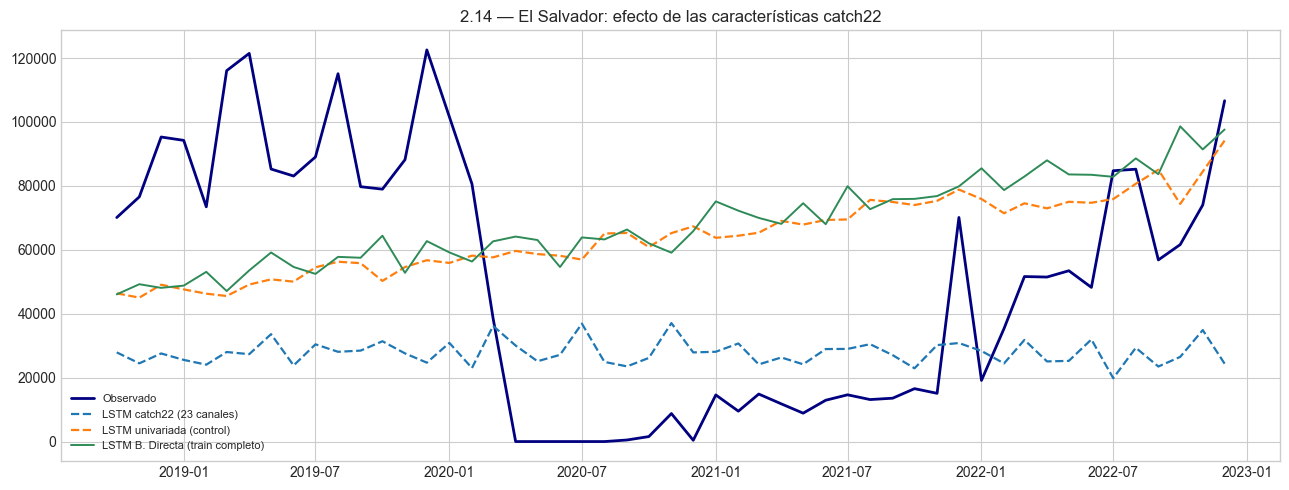

In [23]:
class RedLSTMMulti(nn.Module):
    def __init__(self, n_canales, unidades, capas, dropout, salida):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_canales, hidden_size=unidades,
                            num_layers=capas, batch_first=True,
                            dropout=dropout if capas > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(unidades, salida)

    def forward(self, x):
        salidas, _ = self.lstm(x)
        return self.fc(self.dropout(salidas[:, -1, :]))


def entrenar_c22(train_serie, features, test_serie, config, semilla,
                 lookback=LOOKBACK_C22, usar_features=True):
    fijar_semilla(semilla)
    horizonte = len(test_serie)

    escalador_y = preparar_escalador(train_serie)
    y_esc = escalar(train_serie.to_numpy(), escalador_y)

    if usar_features:
        f_train = features.loc[train_serie.index]
        esc_f = StandardScaler().fit(f_train.to_numpy())
        F = esc_f.transform(f_train.to_numpy())
        canales = np.column_stack([y_esc, F]).astype("float32")
    else:
        canales = y_esc.reshape(-1, 1).astype("float32")

    X, y = [], []
    for i in range(len(canales) - lookback - horizonte + 1):
        X.append(canales[i:i + lookback])
        y.append(y_esc[i + lookback:i + lookback + horizonte])
    if len(X) < 8:
        raise RuntimeError(f"Solo {len(X)} ventanas: insuficiente")
    X = torch.tensor(np.asarray(X, dtype="float32"))
    y = torch.tensor(np.asarray(y, dtype="float32"))

    corte = max(1, int(len(X) * 0.85))
    X_tr, y_tr, X_va, y_va = X[:corte], y[:corte], X[corte:], y[corte:]
    if len(X_va) == 0:
        X_va, y_va = X_tr[-1:], y_tr[-1:]

    modelo = RedLSTMMulti(canales.shape[1], config["unidades"], config["capas"],
                          config["dropout"], horizonte)
    opt = torch.optim.Adam(modelo.parameters(), lr=config["lr"])
    perdida_fn = nn.MSELoss()
    mejor, estado, sin_mejora = float("inf"), None, 0

    for _ in range(config["epochs"]):
        modelo.train()
        for i in range(0, len(X_tr), config["batch"]):
            opt.zero_grad()
            perdida_fn(modelo(X_tr[i:i + config["batch"]]),
                       y_tr[i:i + config["batch"]]).backward()
            opt.step()
        modelo.eval()
        with torch.no_grad():
            val = perdida_fn(modelo(X_va), y_va).item()
        if val < mejor - 1e-6:
            mejor, sin_mejora = val, 0
            estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA:
                break
    if estado:
        modelo.load_state_dict(estado)

    modelo.eval()
    with torch.no_grad():
        pred_esc = modelo(torch.tensor(canales[-lookback:].reshape(1, lookback, -1))).numpy().ravel()
    return pd.Series(desescalar(pred_esc, escalador_y), index=test_serie.index)


config_c22 = cfg("directa", LOOKBACK_C22, 64, 1, 0.2, lr=5e-4)
predicciones_c22 = {}
filas_c22 = []

for etiqueta_modelo, usar in [("LSTM catch22 (23 canales)", True),
                              ("LSTM univariada (control)", False)]:
    preds = [entrenar_c22(train_alin, features_roll, test_alin, config_c22, s, usar_features=usar)
             for s in SEMILLAS]
    pred_media = pd.concat(preds, axis=1).mean(axis=1)
    m = metricas(test_alin.to_numpy(), pred_media)
    filas_c22.append({"Modelo": etiqueta_modelo, "n_train": len(train_alin), **m})
    predicciones_c22[etiqueta_modelo] = pred_media

filas_c22.append({"Modelo": "LSTM B. Directa (Lab 2, train completo)",
                  "n_train": len(train_obj),
                  **{k: resultados_lstm[SERIE_C22]["B. Directa"][k] for k in ("MAE", "RMSE")}})
nombre_l1, mae_l1, rmse_l1 = baseline_lab1[SERIE_C22]
filas_c22.append({"Modelo": f"{nombre_l1} (Lab 1)", "n_train": len(train_obj),
                  "MAE": mae_l1, "RMSE": rmse_l1})

tabla_c22 = pd.DataFrame(filas_c22).sort_values("RMSE").reset_index(drop=True)
display(tabla_c22.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_alin, color="navy", lw=2, label="Observado")
for nombre, pred in predicciones_c22.items():
    ax.plot(pred, lw=1.6, ls="--", label=nombre)
ax.plot(resultados_lstm[SERIE_C22]["B. Directa"]["pred"], color="seagreen",
        lw=1.4, label="LSTM B. Directa (train completo)")
ax.set_title(f"2.14 — {SERIE_C22}: efecto de las características catch22")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Discusión (2.14)

Resultados sobre El Salvador, mismo conjunto de prueba de 51 meses:

| Modelo | n_train | MAE | RMSE |
|---|---|---|---|
| LSTM catch22 (23 canales) | 93 | 38,660 | 45,955 |
| LSTM univariada (control) | 93 | 42,336 | 46,526 |
| LSTM B. Directa (train completo) | 117 | 43,830 | 47,997 |
| ARIMA(4,1,3) (Lab 1) | 117 | 42,141 | 53,001 |

El modelo con catch22 tiene el menor RMSE y el menor MAE de los cuatro, pero
la comparación que importa es contra el control con el mismo `n_train`. Ahí la
diferencia en RMSE es de 571 unidades (−1.2%), muy por debajo de la desviación
entre semillas medida en el tuneo (alrededor de 1,400). No hay evidencia de
que las características mejoren el RMSE.

En MAE la diferencia sí es mayor: 38,660 contra 42,336 (−8.7%). Es consistente
con la forma de las curvas: el modelo con catch22 se queda plano cerca de
28,000 y acierta el mes típico del período 2020-2021, donde lo observado está
cerca de cero, pero falla más en 2019, cuando lo observado llegaba a 120,000.

El efecto más grande no viene de catch22 sino del recorte de datos. El control
con 93 meses supera al Modelo B con 117 meses (46,526 contra 47,997, −3.1%).
Quitar los 24 meses más antiguos mejoró el pronóstico, porque son los de
crecimiento más fuerte y los que enseñaban la tendencia alcista que perjudicó
a los modelos.

Las dos predicciones tienen trayectorias muy distintas, una plana en 28,000 y
otra que sube hasta 95,000, y sin embargo su RMSE difiere en 1.2%. Ambas están
alrededor del 92% del promedio de prueba. A esa escala de error el RMSE ya no
distingue entre modelos.

### Limitaciones

1. Con `n_train = 93`, `lookback = 12` y horizonte 51 quedan 31 ventanas de
   entrenamiento, de las cuales 26 se usan para ajustar y 5 para validación
   interna. Contra eso hay 23 canales de entrada, así que el modelo está
   sobreparametrizado.
2. La configuración no se volvió a tunear para 23 canales: se reutilizó la
   ganadora del Modelo B univariado.
3. Dos de las 22 características se descartaron por varianza nula dentro del
   entrenamiento.
4. Las características se calculan sobre ventanas de 24 meses, que es poco
   para estimar propiedades como el escalamiento DFA, así que varias de ellas
   son ruidosas.